In [6]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings("ignore") #turns off annoying warnings

In [7]:
def pl33tn_numpy(x, dt=2.0, T=33.0, mode="valid", t=None):
    """
    Apply PL33 low-pass filter to a 1D NumPy array `x`.

    Parameters
    ----------
    x : ndarray
        1D input time series (e.g. hourly data).
    dt : float, optional
        Sampling interval in hours (default is 1.0).
    T : float, optional
        Filter half-amplitude period in hours (default is 33.0).
    mode : str, optional
        Convolution mode: 'valid' or 'same' (default is 'valid').
    t : ndarray, optional
        Optional time vector for output.

    Returns
    -------
    xf : ndarray
        Filtered time series.
    tf : ndarray (optional)
        Adjusted time vector (if `t` is provided).
    """

    # Rosenfeld (1983) PL33 filter weights
    base_filter = np.array([
        -0.00027, -0.00114, -0.00211, -0.00317, -0.00427, -0.00537, -0.00641,
        -0.00735, -0.00811, -0.00864, -0.00887, -0.00872, -0.00816, -0.00714,
        -0.00560, -0.00355, -0.00097, +0.00213, +0.00574, +0.00980, +0.01425,
        +0.01902, +0.02400, +0.02911, +0.03423, +0.03923, +0.04399, +0.04842,
        +0.05237, +0.05576, +0.05850, +0.06051, +0.06174, +0.06215, +0.06174,
        +0.06051, +0.05850, +0.05576, +0.05237, +0.04842, +0.04399, +0.03923,
        +0.03423, +0.02911, +0.02400, +0.01902, +0.01425, +0.00980, +0.00574,
        +0.00213, -0.00097, -0.00355, -0.00560, -0.00714, -0.00816, -0.00872,
        -0.00887, -0.00864, -0.00811, -0.00735, -0.00641, -0.00537, -0.00427,
        -0.00317, -0.00211, -0.00114, -0.00027
    ])
    base_dt = np.linspace(-33, 33, 67)

    # Adjust filter based on sampling rate and target half-amplitude period
    dt_scaled = dt * (33.0 / T)
    interp_times = np.arange(0.0, 33.0, dt_scaled)
    interp_times = np.hstack((-interp_times[::-1][:-1], interp_times))  # symmetric

    # Interpolate filter to match new dt
    filter_weights = np.interp(interp_times, base_dt, base_filter)
    filter_weights /= filter_weights.sum()  # normalize

    # Apply convolution
    xf = np.convolve(x, filter_weights, mode=mode)

    if t is not None:
        Nt = len(filter_weights)
        if mode == "valid":
            tf = t[Nt // 2 : -Nt // 2]
        elif mode == "same":
            tf = t
        return xf, tf

    return xf


In [8]:
# Time step
dt_hours = 2
n_samples = 360
pl33_length = 33

# Create full time vector in days
time_hours = np.arange(n_samples) * dt_hours
time_days = time_hours / 24

# Compute valid time vector
offset = (pl33_length - 1) // 2  # 33
time_days_valid = time_days[offset : -offset]  # shape (328,)

print(f"Original time shape: {time_days.shape}")
print(f"Valid time shape:    {time_days_valid.shape}")


Original time shape: (360,)
Valid time shape:    (328,)


In [9]:
# --- Settings ---
energy_dir = "../energy_outputs"
mixing_dir = "../mixing_outputs"
salt_dr = "../sss_outputs"
desired_res = ["1km"]
valid_layers = ["z5", "z10", "z50", "z100"]
time_step_hours = 2  # adjust if different

# PL33 filter length
pl33_length = 33
pad = (pl33_length - 1) // 2

# Color map
color_map = {
    "z5": "magenta",
    "z10": "blue",
    "z50": "k",
    "z100": "red"
}
linestyle = "-"

# === Load Energy Files ===
energy = {"tke": {}, "mke": {}, "eke": {}}

for fname in os.listdir(energy_dir):
    if not fname.endswith(".nc"):
        continue
    parts = fname.replace(".nc", "").split('_')
    if len(parts) < 4:
        continue
    res_key, layer, kind = parts[0], parts[1], parts[2]
    if res_key in desired_res and kind in energy:
        energy[kind].setdefault(layer, {})[res_key] = os.path.join(energy_dir, fname)

# === Load Mixing Files ===
mixing = {"mnum": {}, "mphy": {}}

for fname in os.listdir(mixing_dir):
    if not fname.endswith(".npy"):
        continue
    parts = fname.replace(".npy", "").split('_')
    if len(parts) < 5:
        continue
    kind, hres, zres = parts[0], parts[3], parts[4]
    if hres in desired_res and zres in valid_layers:
        mixing[kind].setdefault(zres, {})[hres] = os.path.join(mixing_dir, fname)

# === Load sss Files ===
salt = {"sss": {}}

for fname in os.listdir(mixing_dir):
    if not fname.endswith(".npy"):
        continue
    parts = fname.replace(".npy", "").split('_')
    if len(parts) < 5:
        continue
    kind, hres, zres = parts[0], parts[3], parts[4]
    if hres in desired_res and zres in valid_layers:
        sss[kind].setdefault(zres, {})[hres] = os.path.join(mixing_dir, fname)

KeyError: 'mtot'

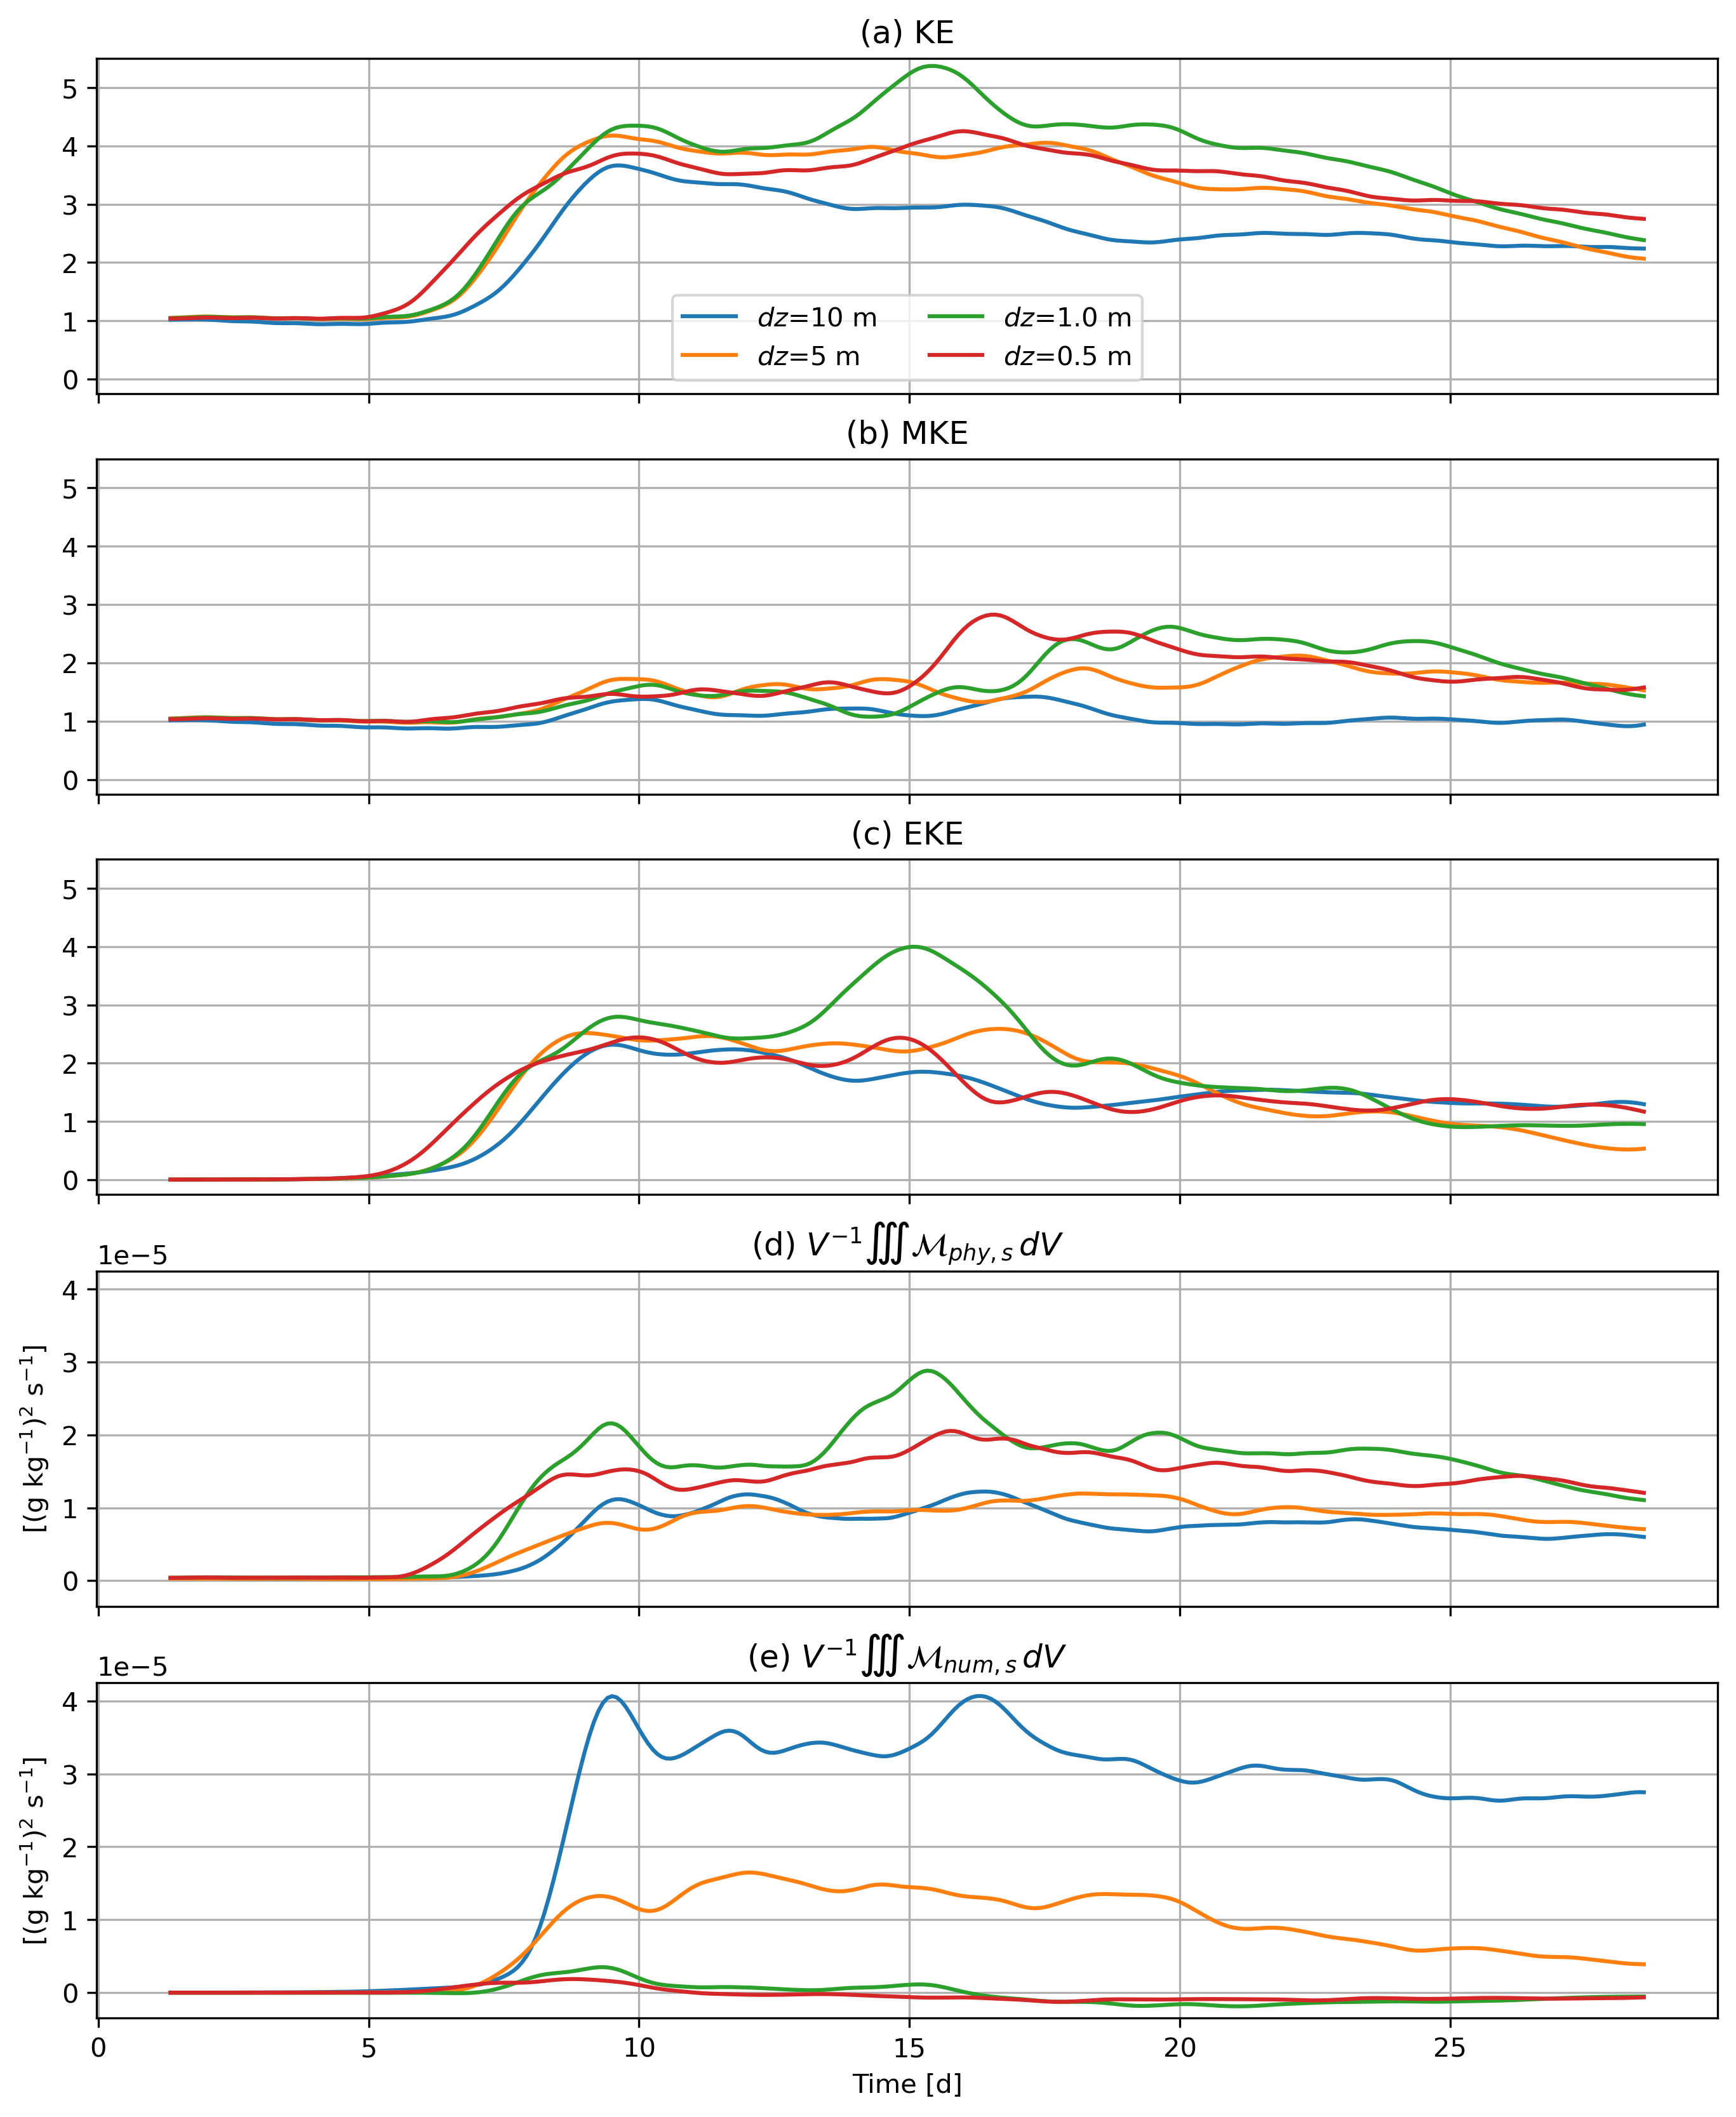

In [5]:
# === Set up figure ===
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(9, 11), sharex=True, constrained_layout=True, dpi=300)
titles = [
    "KE", "MKE", "EKE",
    r"[(g kg$^{-1}$)$^2$ s$^{-1}$]",
    r"[(g kg$^{-1}$)$^2$ s$^{-1}$]"
]

# Custom labels for legend keyed by vertical resolution
custom_labels = {
    "z5": "$dz$=10 m",
    "z10": "$dz$=5 m",
    "z50": "$dz$=1.0 m",
    "z100": "$dz$=0.5 m"
}

# === Plot ENERGY (top 3 rows) ===
for i, kind in enumerate(["tke", "mke", "eke"]):
    for layer in valid_layers:
        for res_key in desired_res:
            path = energy[kind].get(layer, {}).get(res_key)
            if path is None:
                continue

            ds = xr.open_dataset(path)
            varname = list(ds.data_vars)[0]
            data = pl33tn_numpy(ds[varname], mode="valid")

            # Label without resolution part
            label = custom_labels.get(layer, layer)

            axes[i].plot(
                time_days_valid,
                data,
                label=label,
                linestyle=linestyle,
                # color=color_map[layer]
            )

# === Plot MIXING (bottom 2 rows) ===
for j, kind in enumerate(["mphy", "mnum"]):
    ax_idx = 3 + j
    for zres in valid_layers:
        for hres in desired_res:
            path = mixing[kind].get(zres, {}).get(hres)
            if path is None:
                continue

            data = np.load(path)
            data = pl33tn_numpy(data, mode="valid")

            label = custom_labels.get(zres, zres)

            axes[ax_idx].plot(
                time_days_valid,
                data,
                label=label,
                linestyle=linestyle,
                # color=color_map[zres]
            )

# === Formatting ===
for i, ax in enumerate(axes):
    ax.set_ylabel(titles[i])
    ax.grid(True)

axes[0].legend(ncol=2, loc='lower center')
axes[-1].set_xlabel("Time [d]")

axes[0].set_title(r'(a) KE')
axes[1].set_title(r'(b) MKE')
axes[2].set_title(r'(c) EKE')
axes[3].set_title(r'(d) $V^{-1} \iiint \mathcal{M}_{phy,s} \, dV$')
axes[4].set_title(r'(e) $V^{-1} \iiint \mathcal{M}_{num,s} \, dV$')

for i in range(3):
    axes[i].set_ylim(-.25,5.5)
    axes[i].set_ylabel('')

axes[-2].set_ylim(-.35e-5,4.25e-5)
axes[-1].set_ylim(-.35e-5,4.25e-5)

# === Save or Show ===
plt.savefig("bichan_vres_1km.png", dpi=300)
# plt.show()

In [6]:
# --- Settings ---
import re 

# --- Settings ---
energy_dir = "../energy_outputs"
mixing_dir = "../mixing_outputs"
desired_res = ["500m", "1km", "2km", "5km", "10km"]
valid_layers = ["z50"]
time_step_hours = 2  # Adjust if different

# PL33 filter length
pl33_length = 33
pad = (pl33_length - 1) // 2

# Color map
# color_map = {
#     "10km": "magenta",
#     "5km": "blue",
#     "1km": "k",
#     "500m": "red"
# }
linestyle = "-"

# === Load Energy Files ===
energy = {"tke": {}, "mke": {}, "eke": {}}

def extract_time_index(fname):
    """
    Extract timestep index from filename like '500m_z50_eke_vavg_T0000_0001.nc'.
    """
    match = re.search(r'T\d+_(\d+)', fname)
    return int(match.group(1)) if match else -1  # Fallback to -1 if no match

# Load files into dictionary
for fname in os.listdir(energy_dir):
    if not fname.endswith(".nc"):
        continue
    parts = fname.replace(".nc", "").split('_')
    if len(parts) < 4:
        continue
    res_key, layer, kind = parts[0], parts[1], parts[2]
    if res_key in desired_res and kind in energy:
        energy[kind].setdefault(layer, {}).setdefault(res_key, []).append(
            os.path.join(energy_dir, fname)
        )

# === Sort energy file lists by timestep ===
for kind in energy:
    for layer in energy[kind]:
        for res_key in energy[kind][layer]:
            energy[kind][layer][res_key].sort(
                key=lambda f: extract_time_index(os.path.basename(f))
            )

# === Load Mixing Files ===
mixing = {"mnum": {}, "mphy": {}}

for fname in os.listdir(mixing_dir):
    if not fname.endswith(".npy"):
        continue
    parts = fname.replace(".npy", "").split('_')
    if len(parts) < 5:
        continue
    kind, hres, zres = parts[0], parts[3], parts[4]
    if hres in desired_res and zres in valid_layers:
        mixing[kind].setdefault(zres, {})[hres] = os.path.join(mixing_dir, fname)

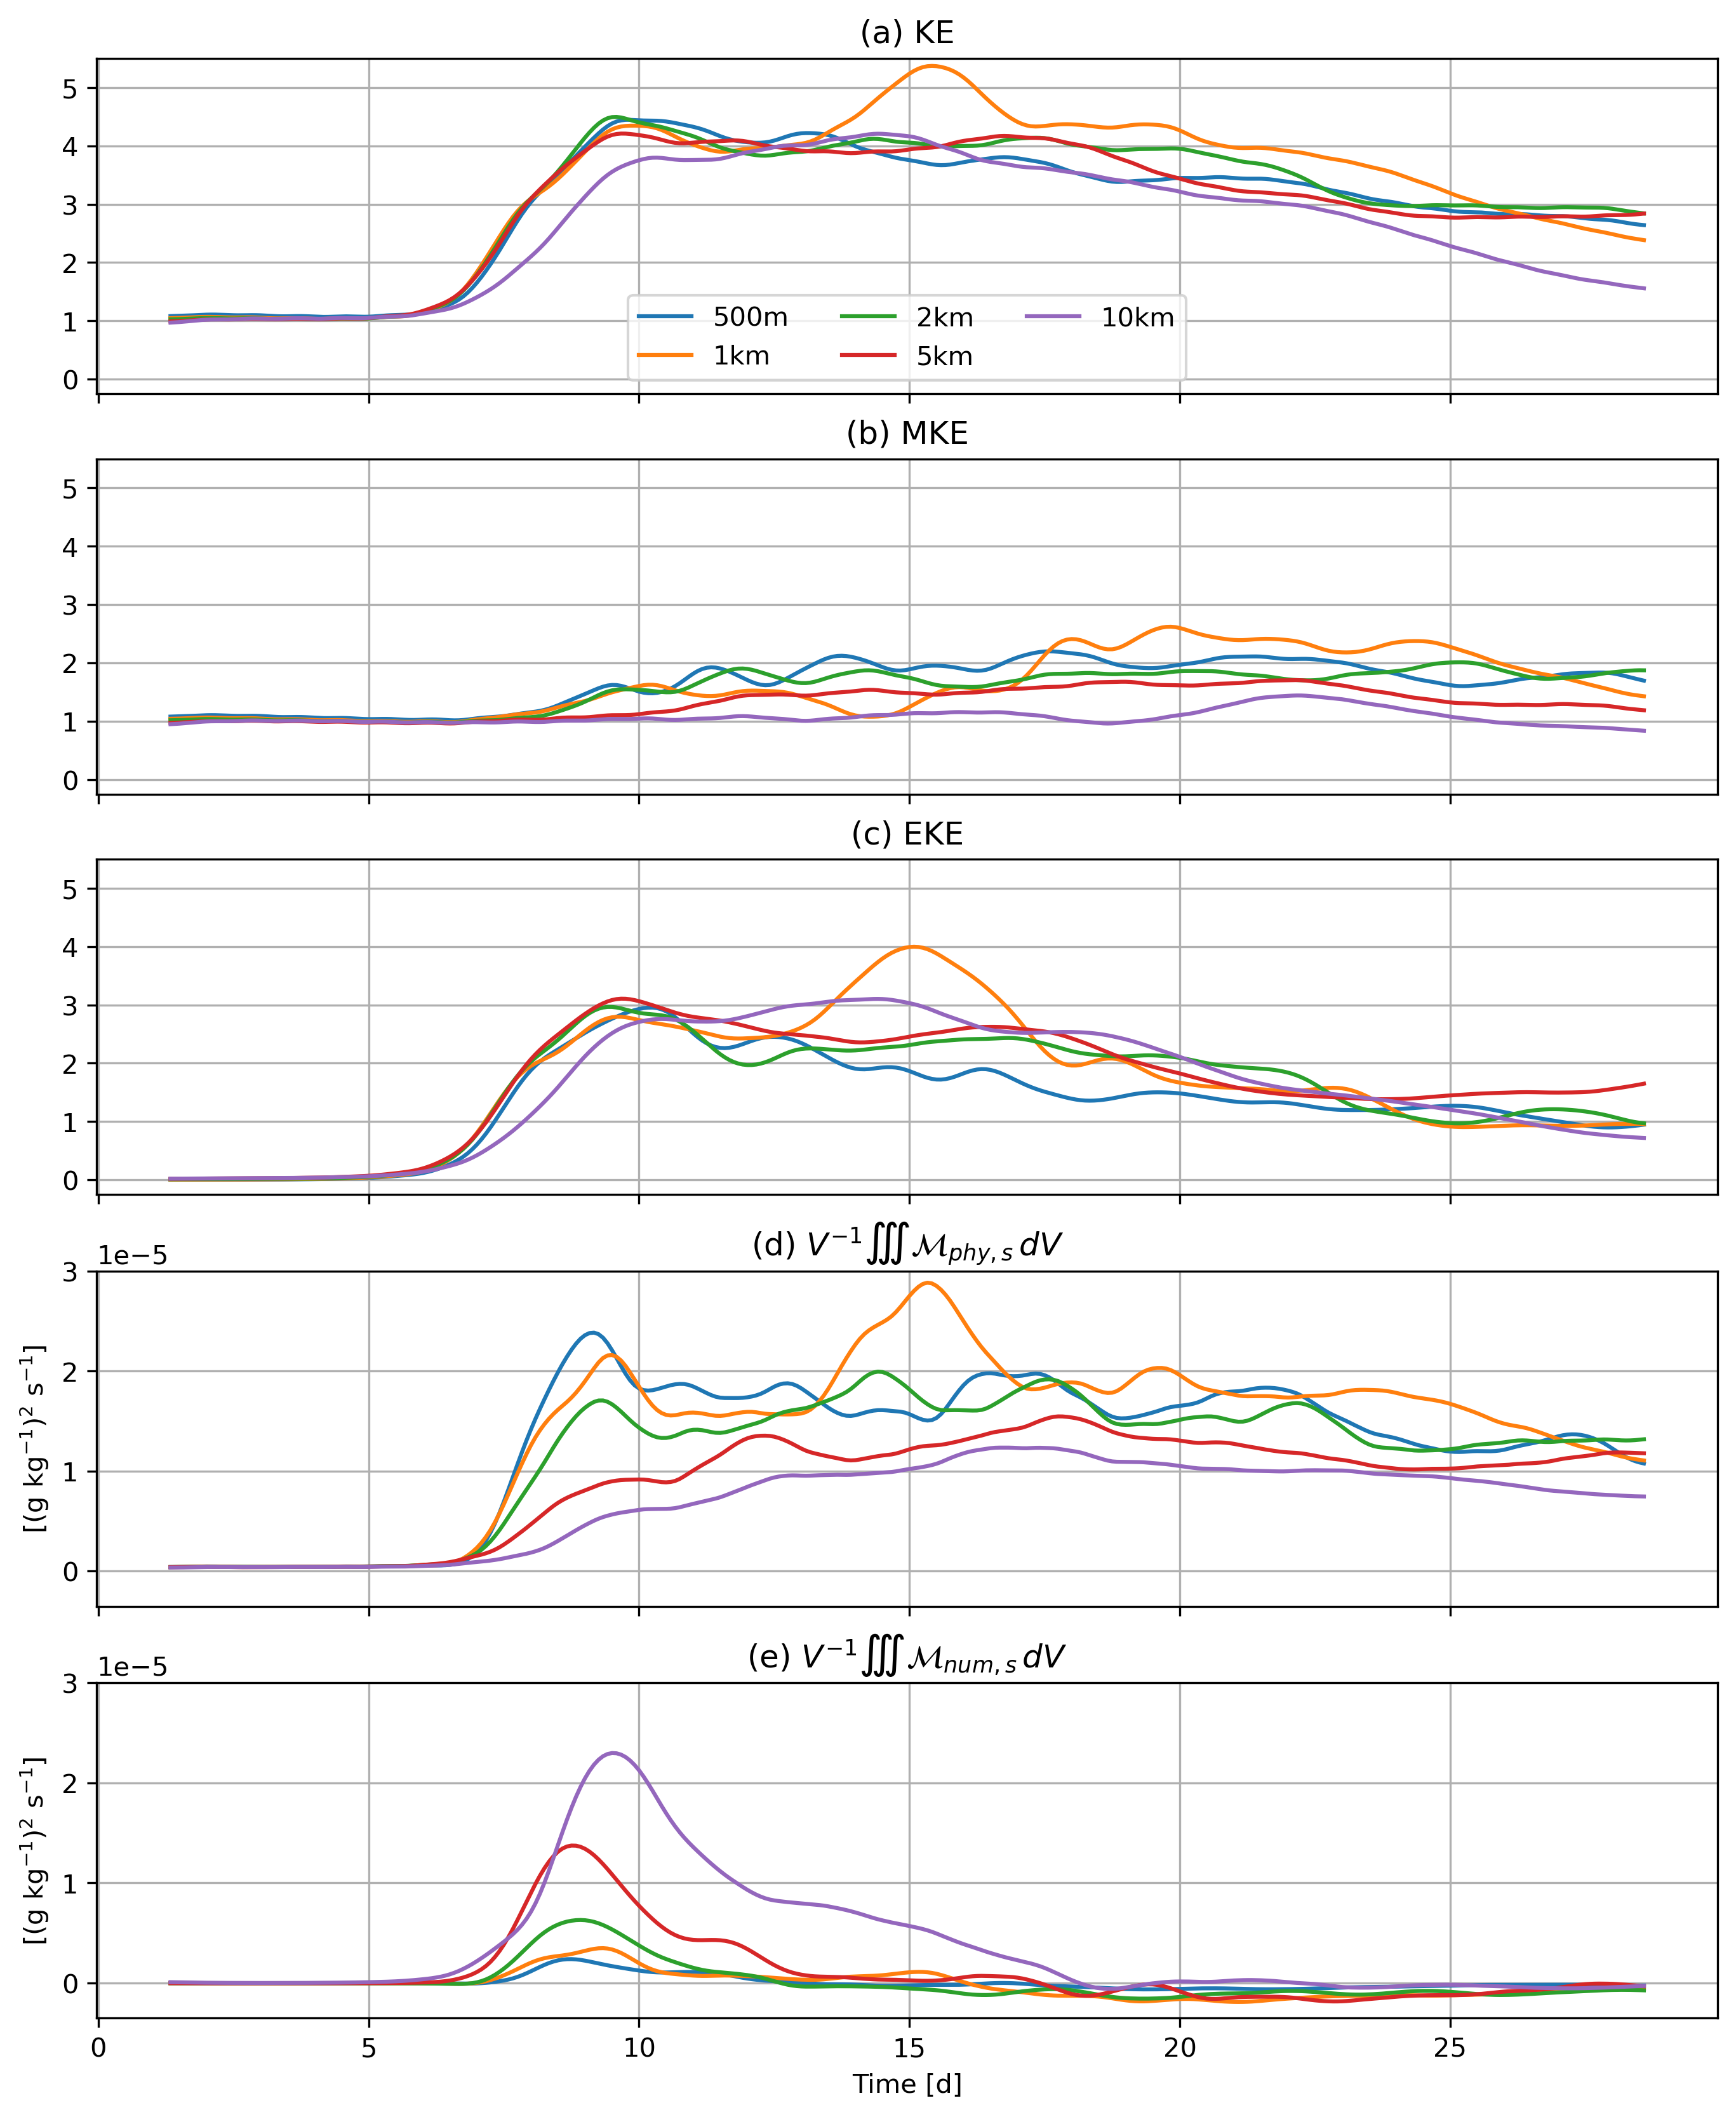

In [8]:
# === Set up figure ===
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(9, 11), sharex=True, constrained_layout=True, dpi=300)
titles = [
    "KE", "MKE", "EKE",
    r"[(g kg$^{-1}$)$^2$ s$^{-1}$]",
    r"[(g kg$^{-1}$)$^2$ s$^{-1}$]"
]

# Custom labels for legend keyed by vertical resolution
custom_labels = {
    "10 km": "$dz$=10 m",
    "5 km": "$dz$=5 m",
    "1 km": "$dz$=1.0 m",
    "0.5 km": "$dz$=0.5 m"
}

# === Plot ENERGY (top 3 rows) ===
import os

# === Plot ENERGY (top 3 rows) ===
for i, kind in enumerate(["tke", "mke", "eke"]):
    for layer in valid_layers:
        for res_key in desired_res:
            paths = energy[kind].get(layer, {}).get(res_key)
            if not paths:
                continue

            if isinstance(paths, str):
                paths = [paths]

            ext = os.path.splitext(paths[0])[1]

            if ext == ".nc":
                ds = xr.open_mfdataset(paths, combine='nested', concat_dim='Time')
                varname = list(ds.data_vars)[0]
                data_raw = ds[varname].values

            elif ext == ".npy":
                arrays = [np.load(p) for p in sorted(paths)]
                data_raw = np.concatenate(arrays)

            else:
                print(f"Skipping unknown file type: {paths[0]}")
                continue

            # print(len(data_raw))
            data = pl33tn_numpy(data_raw, mode="valid")
            # print(len(data))

            # Align time with filtered data length
            # time_plot = time_days_valid[:len(data)]

            label = custom_labels.get(res_key, res_key)
            color = color_map.get(res_key, "gray")

            axes[i].plot(
                time_days_valid,
                data,
                label=label,
                linestyle=linestyle,
                # color=color
            )


# === Plot MIXING (bottom 2 rows) ===
for j, kind in enumerate(["mphy", "mnum"]):
    ax_idx = 3 + j
    for zres in valid_layers:
        for hres in desired_res:
            path = mixing[kind].get(zres, {}).get(hres)
            if path is None:
                continue

            data = np.load(path)
            data = pl33tn_numpy(data, mode="valid")

            label = custom_labels.get(hres, hres)  # Match horizontal resolution
            color = color_map.get(hres, "gray")    # Get color for hres

            axes[ax_idx].plot(
                time_days_valid,
                data,
                label=label,
                linestyle=linestyle,
                # color=color
            )


# === Formatting ===
for i, ax in enumerate(axes):
    ax.set_ylabel(titles[i])
    ax.grid(True)

axes[0].legend(ncol=3, loc='lower center')
axes[-1].set_xlabel("Time [d]")

axes[0].set_title(r'(a) KE')
axes[1].set_title(r'(b) MKE')
axes[2].set_title(r'(c) EKE')
axes[3].set_title(r'(d) $V^{-1} \iiint \mathcal{M}_{phy,s} \, dV$')
axes[4].set_title(r'(e) $V^{-1} \iiint \mathcal{M}_{num,s} \, dV$')

for i in range(3):
    axes[i].set_ylim(-.25,5.5)
    axes[i].set_ylabel('')

axes[-2].set_ylim(-.35e-5,3e-5)
axes[-1].set_ylim(-.35e-5,3e-5)

# === Save or Show ===
plt.savefig("bichan_hres_1mdz.png", dpi=300)
# plt.show()